In [1]:
# Libs Necessárias

# Libs para Modelagem e Matrizez
import numpy as np
import pandas as pd

# Libs para anaálises gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Lib para ignorar avisos
import warnings

# Desabilitando avisos
warnings.filterwarnings('ignore')

In [30]:
Base_Dados = pd.read_csv('amazon_delivery.csv', sep=',', encoding='utf-8')

Base_Dados.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [6]:
Base_Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [7]:
Base_Dados.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [8]:
# Estatisticas
Base_Dados.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [64]:
ordem_area = Base_Dados.groupby('Area')['Delivery_Time'].mean().round(0).sort_values(ascending=False)

ordem_area.head()

Area
Semi-Urban        239.0
Metropolitian     130.0
Urban             109.0
Other             104.0
Name: Delivery_Time, dtype: float64

In [65]:
ordem_veiculo = Base_Dados.groupby('Vehicle')['Delivery_Time'].mean().round(0).sort_values(ascending=False)

ordem_veiculo.head()

Vehicle
motorcycle     131.0
bicycle        127.0
scooter        116.0
van            116.0
Name: Delivery_Time, dtype: float64

In [66]:
ordem_clima = Base_Dados.groupby('Weather')['Delivery_Time'].mean().round(0).sort_values(ascending=False)

ordem_clima.head()

Weather
Cloudy        138.0
Fog           137.0
Windy         124.0
Sandstorms    123.0
Stormy        123.0
Name: Delivery_Time, dtype: float64

In [67]:
ordem_trafego = Base_Dados.groupby('Traffic')['Delivery_Time'].mean().round(0).sort_values(ascending=False)

ordem_trafego.head()

Traffic
Jam        148.0
High       129.0
Medium     127.0
NaN        121.0
Low        101.0
Name: Delivery_Time, dtype: float64

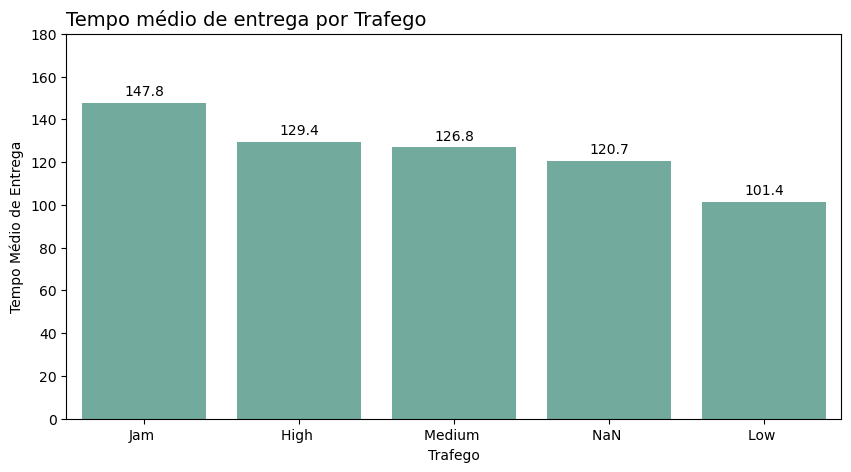

In [50]:
# Imagem
plt.figure(figsize=(10,5))

# Titulo
plt.title('Tempo médio de entrega por Trafego', loc='Left', fontsize=14)

# Gráfico
ax = sns.barplot(data=Base_Dados.sort_values(by='Delivery_Time', ascending=False), x='Traffic', y='Delivery_Time', ci=None, color='#69b3a2', estimator=np.mean)

# Labels
plt.xlabel('Trafego')
plt.ylabel('Tempo Médio de Entrega');

# 2. Rótulos das barras
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

# 3. Aumenta o limite do eixo Y (de 0 até 180)
ax.set_ylim(0, 180);

(0.0, 300.0)

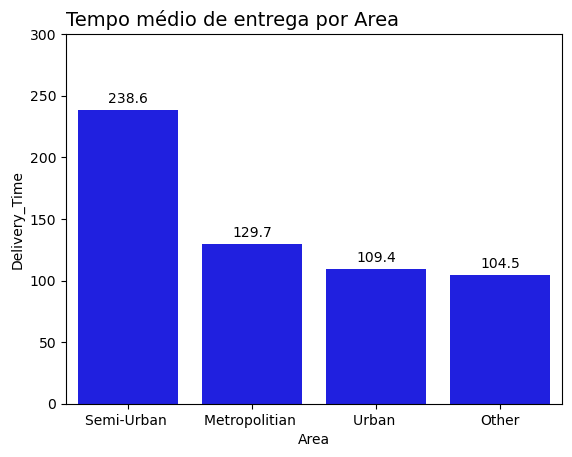

In [48]:
# 1. Calcula a ordem decrescente das médias
ordem_area = Base_Dados.groupby('Area')['Delivery_Time'].mean().sort_values(ascending=False).index

# 2. Define o título do gráfico
plt.title('Tempo médio de entrega por Area', loc='left', fontsize=14)

# 3. Plot do gráfico
ax = sns.barplot(
    data=Base_Dados, 
    x='Area', 
    y='Delivery_Time', 
    order=ordem_area,
    ci=None, 
    color='blue', 
    estimator=np.mean
) 

# 4. Rótulos das barras
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

# 5. Aumenta o limite do eixo Y (de 0 até 300)
ax.set_ylim(0, 300)

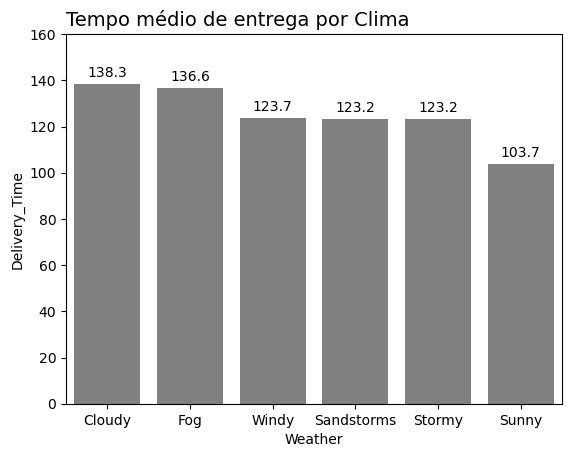

In [54]:
# 1. Calcula a ordem das médias
ordem_area = Base_Dados.groupby('Weather')['Delivery_Time'].mean().sort_values(ascending=False).index

# 2. Define o título do gráfico
plt.title('Tempo médio de entrega por Clima', loc='left', fontsize=14)

# 3. Plot sem espaço/recuo no começo da linha
ax = sns.barplot(
    data=Base_Dados,
    x='Weather',
    y='Delivery_Time',
    order=ordem_area,
    ci=None,
    color='gray',
    estimator=np.mean
)

# 2. Rótulos das barras
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

# 3. Aumenta o limite do eixo Y (de 0 até 160)
ax.set_ylim(0, 160);

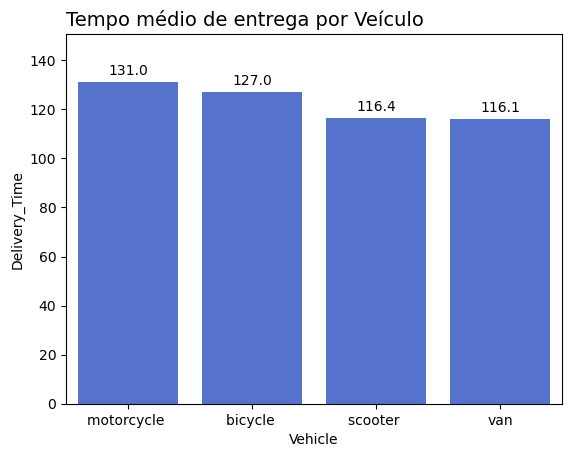

In [52]:
# 1. Calcula a ordem decrescente das médias
ordem_area = Base_Dados.groupby('Vehicle')['Delivery_Time'].mean().sort_values(ascending=False).index

# 2. Define o título do gráfico
plt.title('Tempo médio de entrega por Veículo', loc='left', fontsize=14)

# 3. Plot do gráfico
ax = sns.barplot(
    data=Base_Dados, 
    x='Vehicle', 
    y='Delivery_Time', 
    order=ordem_area,
    ci=None, 
    color='royalblue', 
    estimator=np.mean
) 

# 4. Rótulos das barras
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

ax.margins(y=0.15)  # Adiciona 15% de folga no topo

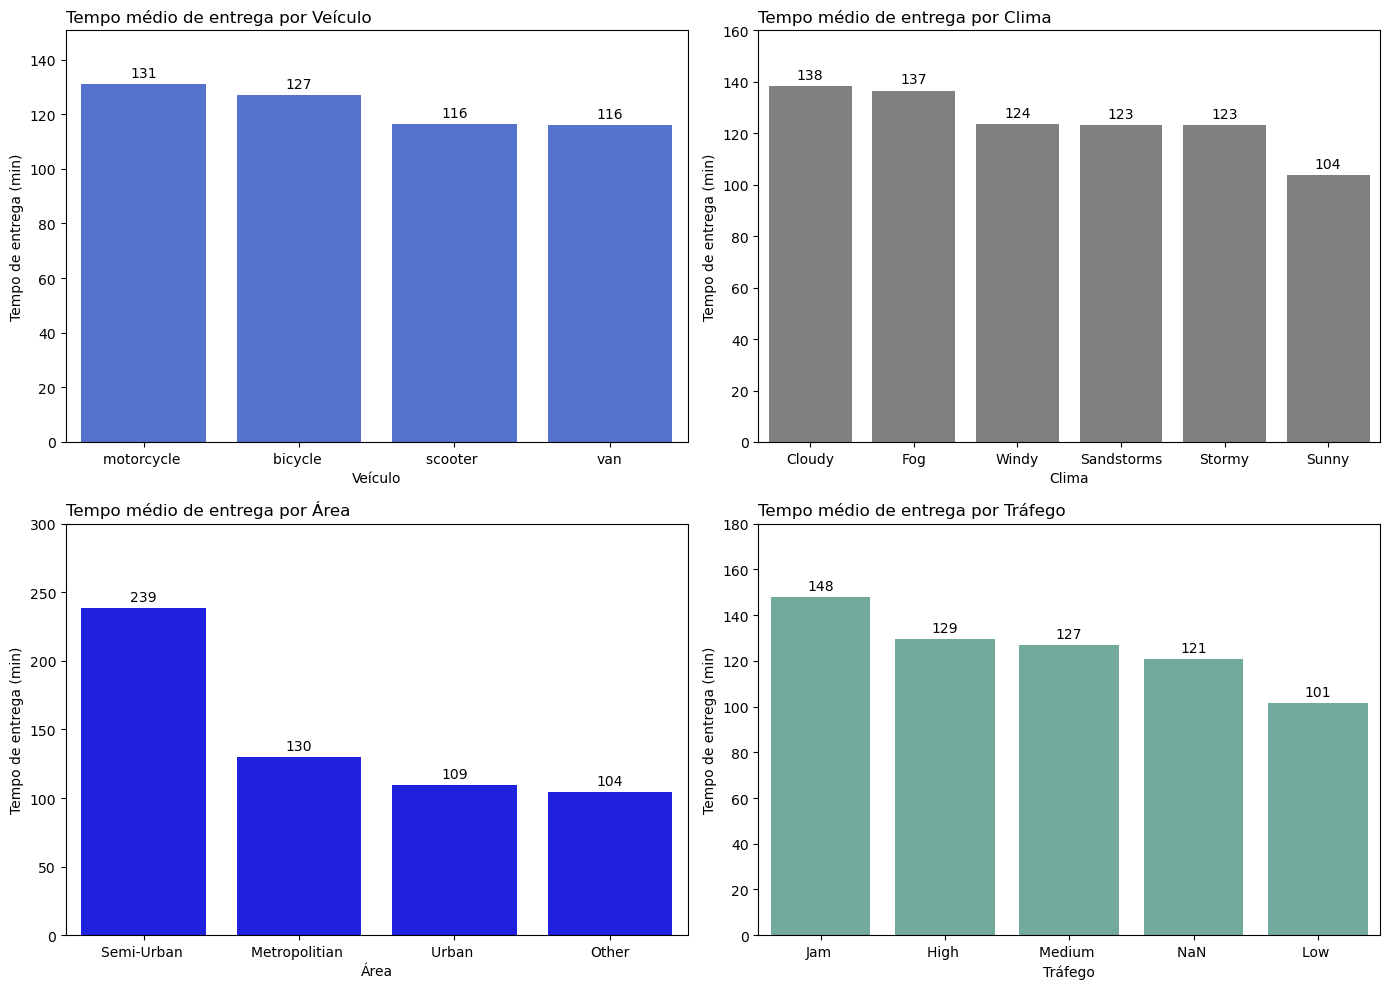

In [58]:
# 1. Cria a figura com 2 linhas e 2 colunas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- GRÁFICO 1: Veículo ---
ordem_veh = Base_Dados.groupby('Vehicle')['Delivery_Time'].mean().sort_values(ascending=False).index
sns.barplot(data=Base_Dados, x='Vehicle', y='Delivery_Time', order=ordem_veh, ci=None, color='royalblue', estimator=np.mean, ax=axes[0, 0])
axes[0, 0].set_title('Tempo médio de entrega por Veículo', loc='left', fontsize=12)
axes[0, 0].set_xlabel('Veículo')
axes[0, 0].set_ylabel('Tempo de entrega (min)')
axes[0, 0].bar_label(axes[0, 0].containers[0], fmt='%.0f', padding=3)
axes[0, 0].margins(y=0.15)

# --- GRÁFICO 2: Clima ---
ordem_wea = Base_Dados.groupby('Weather')['Delivery_Time'].mean().sort_values(ascending=False).index
sns.barplot(data=Base_Dados, x='Weather', y='Delivery_Time', order=ordem_wea, ci=None, color='gray', estimator=np.mean, ax=axes[0, 1])
axes[0, 1].set_title('Tempo médio de entrega por Clima', loc='left', fontsize=12)
axes[0, 1].set_xlabel('Clima')
axes[0, 1].set_ylabel('Tempo de entrega (min)')
axes[0, 1].bar_label(axes[0, 1].containers[0], fmt='%.0f', padding=3)
axes[0, 1].set_ylim(0, 160)

# --- GRÁFICO 3: Área ---
ordem_area = Base_Dados.groupby('Area')['Delivery_Time'].mean().sort_values(ascending=False).index
sns.barplot(data=Base_Dados, x='Area', y='Delivery_Time', order=ordem_area, ci=None, color='blue', estimator=np.mean, ax=axes[1, 0])
axes[1, 0].set_title('Tempo médio de entrega por Área', loc='left', fontsize=12)
axes[1, 0].set_xlabel('Área')
axes[1, 0].set_ylabel('Tempo de entrega (min)')
axes[1, 0].bar_label(axes[1, 0].containers[0], fmt='%.0f', padding=3)
axes[1, 0].set_ylim(0, 300)

# --- GRÁFICO 4: Tráfego ---
ordem_traf = Base_Dados.groupby('Traffic')['Delivery_Time'].mean().sort_values(ascending=False).index
sns.barplot(data=Base_Dados, x='Traffic', y='Delivery_Time', order=ordem_traf, ci=None, color='#69b3a2', estimator=np.mean, ax=axes[1, 1])
axes[1, 1].set_title('Tempo médio de entrega por Tráfego', loc='left', fontsize=12)
axes[1, 1].set_xlabel('Tráfego')
axes[1, 1].set_ylabel('Tempo de entrega (min)')
axes[1, 1].bar_label(axes[1, 1].containers[0], fmt='%.0f', padding=3)
axes[1, 1].set_ylim(0, 180)


# Ajusta o espaçamento
plt.tight_layout()

# 1. SALVA A IMAGEM (coloque antes do plt.show)
plt.savefig('graficos_tempo_entrega.png', dpi=300, bbox_inches='tight')

# 2. Exibe no notebook
plt.show()

In [59]:
from PIL import Image

# 1. Carrega os 4 prints das consultas SQL (coloque os nomes exatos dos seus arquivos)
img_veiculo = Image.open('consulta veiculo.png')
img_clima = Image.open('consulta clima.png')
img_area = Image.open('consulta area.png')
img_trafego = Image.open('consulta trafego.png')

# 2. Padroniza o tamanho das imagens para o painel ficar alinhado
largura, altura = 600, 400
img1 = img_veiculo.resize((largura, altura))
img2 = img_clima.resize((largura, altura))
img3 = img_area.resize((largura, altura))
img4 = img_trafego.resize((largura, altura))

# 3. Cria uma nova imagem vazia de 2x2
imagem_final = Image.new('RGB', (largura * 2, altura * 2), color='white')

# 4. Cola cada imagem na sua posição (Canto superior esquerdo, direito, etc.)
imagem_final.paste(img1, (0, 0))                  # Superior Esquerdo: Veículo
imagem_final.paste(img2, (largura, 0))            # Superior Direito: Clima
imagem_final.paste(img3, (0, altura))             # Inferior Esquerdo: Área
imagem_final.paste(img4, (largura, altura))       # Inferior Direito: Tráfego

# 5. Salva o resultado final
imagem_final.save('consultas_sql_painel.png')
imagem_final.show()